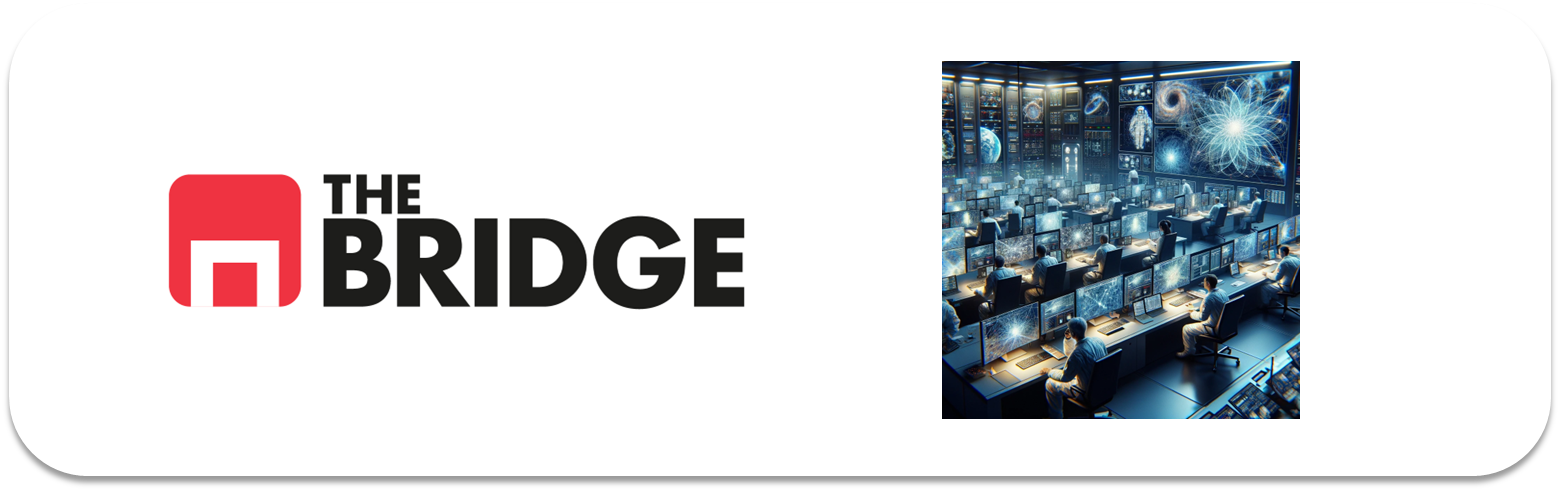

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from bootcampviztools import pinta_distribucion_categoricas

print("TensorFlow version:", tf.__version__)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

IMG_SIZE = (32, 32)
DATA_DIR = "data"
TRAIN_DIRS = ["github_train_0", "github_train_1", "github_train_2", "github_train_3"]
TEST_DIR = "github_test"

TensorFlow version: 2.21.0


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



### 1. Carga de los datasets de train y test

Como se indica en el enunciado, la clase (`cat`/`dog`) está codificada en el propio nombre de fichero. Creamos una función que intenta extraer la clase buscando las subcadenas `cat`/`gato` o `dog`/`perro` (sin distinguir mayúsculas/minúsculas) en el nombre del archivo. Si un nombre no permite determinar la clase con seguridad (por ejemplo, porque la imagen no es ni de un perro ni de un gato, como avisa el enunciado que puede pasar en `github_test`), la descartamos y lo indicamos por pantalla, en lugar de asumir una etiqueta que no podemos garantizar.

Aprovechamos la misma función para leer la imagen y redimensionarla a 32x32 en el momento de la carga, tal como pide el enunciado.

In [2]:
def etiqueta_desde_nombre(filename):
    """
    Extrae la etiqueta ('cat' o 'dog') a partir del nombre de fichero.
    Devuelve None si no se puede determinar con seguridad (nombre ambiguo
    o que no contiene ninguna de las dos palabras clave).
    """
    name = filename.lower()
    es_gato = ("cat" in name) or ("gato" in name)
    es_perro = ("dog" in name) or ("perro" in name)

    if es_gato and not es_perro:
        return "cat"
    if es_perro and not es_gato:
        return "dog"
    return None


def cargar_imagenes(directorio, img_size=IMG_SIZE, verbose=True):
    """
    Lee todas las imágenes de `directorio`, las redimensiona a `img_size`
    y extrae su etiqueta a partir del nombre de fichero.

    Devuelve:
        X (np.array): imágenes como array (n, alto, ancho, 3), valores en [0, 255]
        y (np.array): etiquetas ('cat'/'dog') como array de strings
        rutas (list): ruta de cada imagen, en el mismo orden que X e y
    """
    rutas_totales = sorted(glob.glob(os.path.join(directorio, "*")))

    imagenes, etiquetas, rutas_validas = [], [], []
    descartadas_sin_clase = 0
    descartadas_error_lectura = 0

    for ruta in rutas_totales:
        etiqueta = etiqueta_desde_nombre(os.path.basename(ruta))
        if etiqueta is None:
            descartadas_sin_clase += 1
            continue
        try:
            img = keras.utils.load_img(ruta, target_size=img_size)
            img_array = keras.utils.img_to_array(img)
        except Exception:
            descartadas_error_lectura += 1
            continue

        imagenes.append(img_array)
        etiquetas.append(etiqueta)
        rutas_validas.append(ruta)

    if verbose:
        print(
            f"{directorio}: {len(imagenes)} imágenes cargadas | "
            f"{descartadas_sin_clase} descartadas por nombre no reconocible como cat/dog | "
            f"{descartadas_error_lectura} descartadas por error de lectura"
        )

    X = np.array(imagenes) if imagenes else np.empty((0, *img_size, 3))
    y = np.array(etiquetas)
    return X, y, rutas_validas

In [3]:
# --- Train: concatenamos las imágenes de los 4 directorios ---
X_train_parts, y_train_parts, paths_train = [], [], []

for carpeta in TRAIN_DIRS:
    X_parte, y_parte, rutas_parte = cargar_imagenes(os.path.join(DATA_DIR, carpeta))
    X_train_parts.append(X_parte)
    y_train_parts.append(y_parte)
    paths_train.extend(rutas_parte)

X_train_raw = np.concatenate(X_train_parts, axis=0)
y_train_raw = np.concatenate(y_train_parts, axis=0)

print("\nTotal imágenes de TRAIN:", X_train_raw.shape)

data\github_train_0: 1000 imágenes cargadas | 0 descartadas por nombre no reconocible como cat/dog | 0 descartadas por error de lectura
data\github_train_1: 1000 imágenes cargadas | 0 descartadas por nombre no reconocible como cat/dog | 0 descartadas por error de lectura
data\github_train_2: 1000 imágenes cargadas | 0 descartadas por nombre no reconocible como cat/dog | 0 descartadas por error de lectura
data\github_train_3: 1000 imágenes cargadas | 0 descartadas por nombre no reconocible como cat/dog | 0 descartadas por error de lectura

Total imágenes de TRAIN: (4000, 32, 32, 3)


In [18]:
from sklearn.utils import shuffle

X_train_raw, y_train_raw, paths_train = shuffle(
    X_train_raw, y_train_raw, paths_train, random_state=RANDOM_STATE
)

print("Train barajado. Primeras 10 etiquetas:", y_train_raw[:10])

Train barajado. Primeras 10 etiquetas: ['cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'cat']


In [19]:
# --- Test: pool de imágenes a clasificar y de donde saldrán las "difíciles" ---
X_test_raw, y_test_raw, paths_test = cargar_imagenes(os.path.join(DATA_DIR, TEST_DIR))

print("\nTotal imágenes de TEST:", X_test_raw.shape)

data\github_test: 1000 imágenes cargadas | 0 descartadas por nombre no reconocible como cat/dog | 0 descartadas por error de lectura

Total imágenes de TEST: (1000, 32, 32, 3)


In [20]:
label_map = {"cat": 0, "dog": 1}
inv_label_map = {v: k for k, v in label_map.items()}

y_train = np.array([label_map[l] for l in y_train_raw])
y_test = np.array([label_map[l] for l in y_test_raw])

# Normalizamos los píxeles a [0, 1]
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test :", X_test.shape, " y_test :", y_test.shape)

X_train: (4000, 32, 32, 3)  y_train: (4000,)
X_test : (1000, 32, 32, 3)  y_test : (1000,)


### 2. Visualización, Mini-EDA y construcción del modelo

#### Visualización de instancias

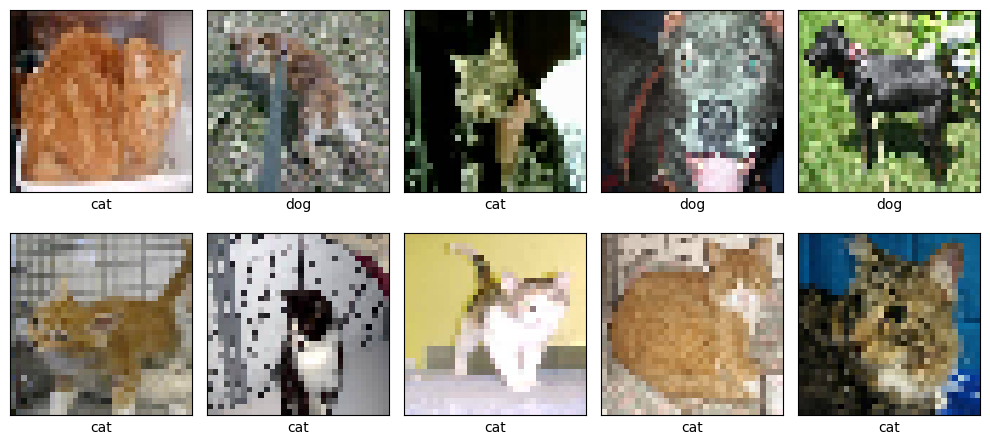

In [21]:
def mostrar_imagenes(images, labels_texto, n=10, cols=5):
    n = min(n, len(images))
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(2 * cols, 2.4 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i])
        plt.xlabel(labels_texto[i])
    plt.tight_layout()
    plt.show()


mostrar_imagenes(X_train, y_train_raw, n=10)

#### Mini-EDA: balance de clases

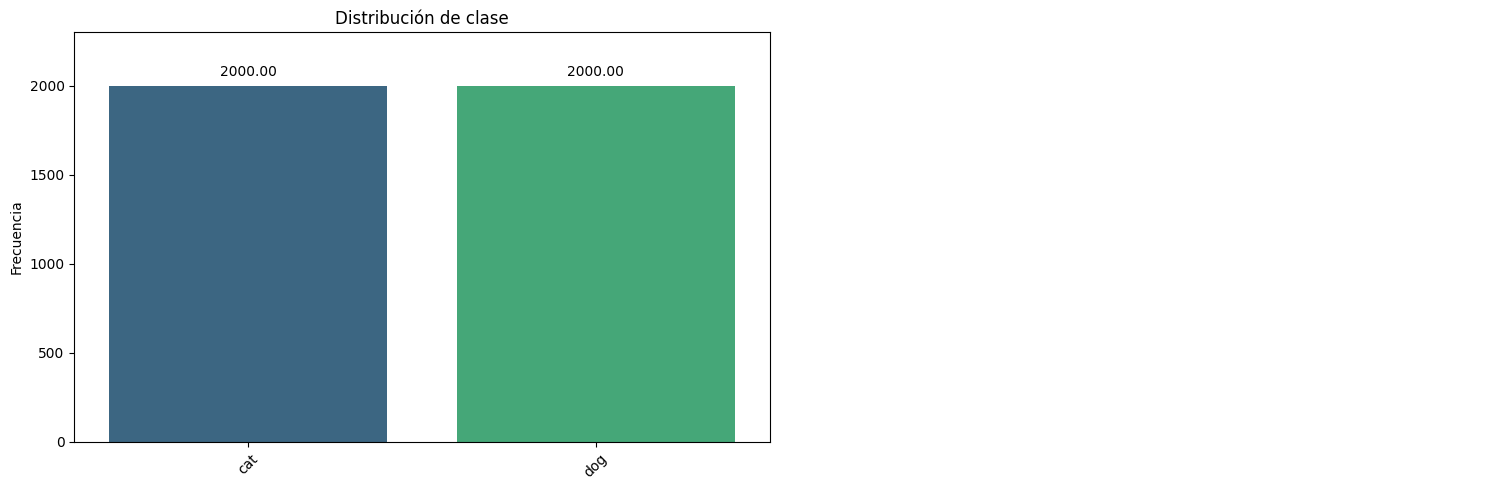

Balance de clases en train:
clase
cat    0.5
dog    0.5
Name: proportion, dtype: float64


In [22]:
df_train_labels = pd.DataFrame({"clase": y_train_raw})
pinta_distribucion_categoricas(df_train_labels, ["clase"], mostrar_valores=True)

print("Balance de clases en train:")
print(df_train_labels["clase"].value_counts(normalize=True))

El dataset de train está prácticamente balanceado entre gatos y perros (2000 imágenes de cada clase, salvo las que se hayan podido descartar por nombre no reconocible), así que no hace falta aplicar ninguna técnica de balanceo de clases antes de entrenar.

#### Construcción del modelo CNN

Definimos una función que construye y compila el modelo, para poder reutilizar exactamente la misma arquitectura más adelante en la parte de *Image Augmentation* (apartado Extra) y comparar resultados de forma justa.

La red tiene **tres bloques Convolucional + MaxPooling** (más de los 2 mínimos que pide el enunciado), seguidos de una capa densa y una capa de salida de **una sola neurona con activación `sigmoid`**, adecuada para clasificación **binaria** (gato vs. perro). Usamos `binary_crossentropy` como función de pérdida, coherente con esa salida sigmoide.

In [23]:
def construir_modelo_cnn():
    modelo = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ], name="cnn_cats_dogs")

    modelo.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return modelo


model = construir_modelo_cnn()
model.summary()

Model: "cnn_cats_dogs"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Entrenamiento con EarlyStopping

Entrenamos reservando un 20% del conjunto de train para validación (`validation_split=0.2`) y con un callback de `EarlyStopping` sobre `val_loss`, con una paciencia de 8 épocas y `restore_best_weights=True` para quedarnos con los pesos del mejor punto de validación, no con los de la última época.

In [24]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=2,
)

Epoch 1/60
100/100 - 5s - 48ms/step - accuracy: 0.5316 - loss: 0.6915 - val_accuracy: 0.5962 - val_loss: 0.6759
Epoch 2/60
100/100 - 3s - 31ms/step - accuracy: 0.6263 - loss: 0.6431 - val_accuracy: 0.6787 - val_loss: 0.6169
Epoch 3/60
100/100 - 3s - 28ms/step - accuracy: 0.6856 - loss: 0.5916 - val_accuracy: 0.6712 - val_loss: 0.6107
Epoch 4/60
100/100 - 3s - 29ms/step - accuracy: 0.7134 - loss: 0.5566 - val_accuracy: 0.6950 - val_loss: 0.5873
Epoch 5/60
100/100 - 2s - 24ms/step - accuracy: 0.7459 - loss: 0.5202 - val_accuracy: 0.6988 - val_loss: 0.5852
Epoch 6/60
100/100 - 3s - 26ms/step - accuracy: 0.7753 - loss: 0.4765 - val_accuracy: 0.6975 - val_loss: 0.5845
Epoch 7/60
100/100 - 3s - 27ms/step - accuracy: 0.8009 - loss: 0.4336 - val_accuracy: 0.7075 - val_loss: 0.6304
Epoch 8/60
100/100 - 2s - 22ms/step - accuracy: 0.8300 - loss: 0.3757 - val_accuracy: 0.6988 - val_loss: 0.6617
Epoch 9/60
100/100 - 2s - 24ms/step - accuracy: 0.8456 - loss: 0.3486 - val_accuracy: 0.7038 - val_loss:

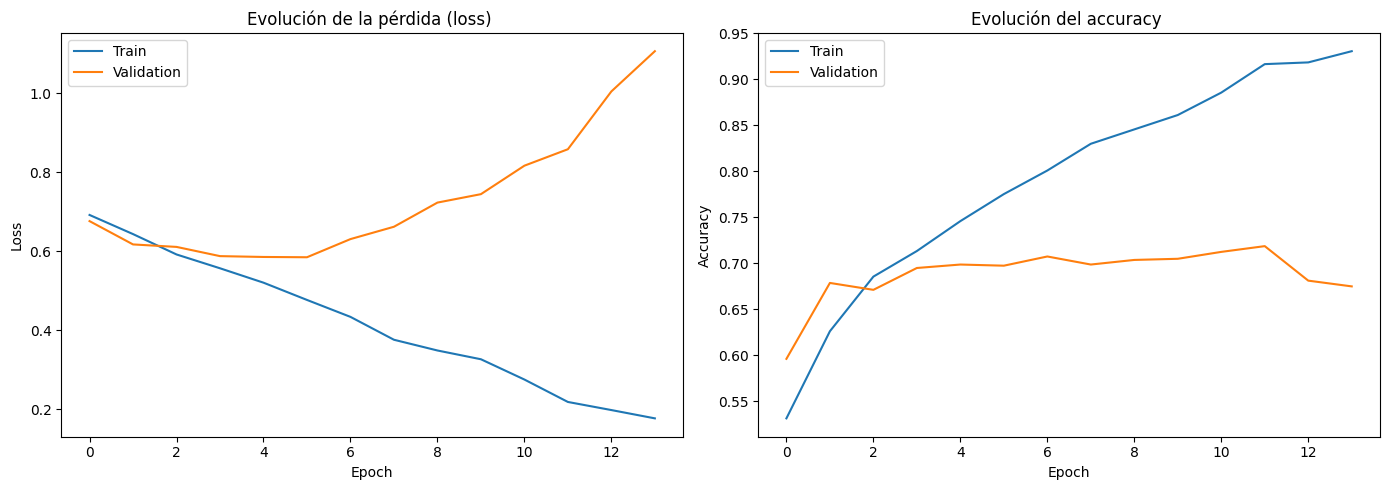

In [25]:
def plot_historial(history, titulo_extra=""):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df["loss"], label="Train")
    axes[0].plot(history_df["val_loss"], label="Validation")
    axes[0].set_title(f"Evolución de la pérdida (loss) {titulo_extra}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_df["accuracy"], label="Train")
    axes[1].plot(history_df["val_accuracy"], label="Validation")
    axes[1].set_title(f"Evolución del accuracy {titulo_extra}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_historial(history)

### 4. Evaluación, reporte de clasificación y matriz de confusión

In [26]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.7220
Test loss:     0.5690


In [27]:
y_pred_probs = model.predict(X_test, verbose=0).ravel()  # P(clase = "dog")
y_pred = (y_pred_probs >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["cat", "dog"]))

              precision    recall  f1-score   support

         cat       0.73      0.71      0.72       500
         dog       0.72      0.74      0.73       500

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.72      0.72      0.72      1000



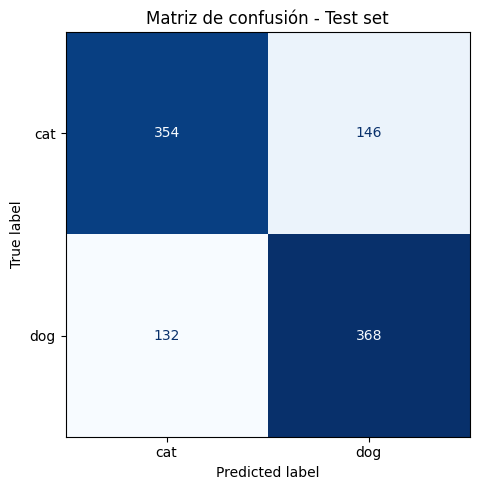

array([[354, 146],
       [132, 368]])

In [28]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Test set")
plt.tight_layout()
plt.show()

cm

### 5. Selección de las imágenes más "difíciles" para el CAPTCHA

Buscamos, dentro de cada clase real, las imágenes **mal clasificadas** con **mayor confianza en la clase incorrecta**: gatos que el modelo cree, con mucha seguridad, que son perros, y perros que el modelo cree, con mucha seguridad, que son gatos. Esas son las imágenes en las que un sistema anti-CAPTCHA automático fallaría más, por lo que son las mejores candidatas para el CAPTCHA.

`y_pred_probs` es la probabilidad de que la imagen sea `dog` (salida de la sigmoide). Para un gato mal clasificado, esa probabilidad ya es directamente la "confianza en la clase incorrecta". Para un perro mal clasificado, la confianza en la clase incorrecta ("cat") es `1 - y_pred_probs`.

Seleccionamos, de cada clase, el 10% del total de imágenes de esa clase en test (redondeando, con un mínimo de 1), tomando las de mayor confianza errónea entre las mal clasificadas.

In [29]:
n_cats_total = int(np.sum(y_test == 0))
n_dogs_total = int(np.sum(y_test == 1))

n_cats_dificiles = max(1, round(0.10 * n_cats_total))
n_dogs_dificiles = max(1, round(0.10 * n_dogs_total))

# Gatos reales clasificados como perro, ordenados por confianza (P(dog)) descendente
idx_cats_mal = np.where((y_test == 0) & (y_pred == 1))[0]
idx_cats_mal = idx_cats_mal[np.argsort(-y_pred_probs[idx_cats_mal])]
idx_cats_dificiles = idx_cats_mal[:n_cats_dificiles]

# Perros reales clasificados como gato, ordenados por confianza (1 - P(dog)) descendente
idx_dogs_mal = np.where((y_test == 1) & (y_pred == 0))[0]
confianza_dogs_mal = 1 - y_pred_probs[idx_dogs_mal]
idx_dogs_mal = idx_dogs_mal[np.argsort(-confianza_dogs_mal)]
idx_dogs_dificiles = idx_dogs_mal[:n_dogs_dificiles]

print(f"Gatos en test: {n_cats_total} -> 10% = {n_cats_dificiles} | "
      f"mal clasificados disponibles: {len(idx_cats_mal)} | seleccionados: {len(idx_cats_dificiles)}")
print(f"Perros en test: {n_dogs_total} -> 10% = {n_dogs_dificiles} | "
      f"mal clasificados disponibles: {len(idx_dogs_mal)} | seleccionados: {len(idx_dogs_dificiles)}")

Gatos en test: 500 -> 10% = 50 | mal clasificados disponibles: 146 | seleccionados: 50
Perros en test: 500 -> 10% = 50 | mal clasificados disponibles: 132 | seleccionados: 50


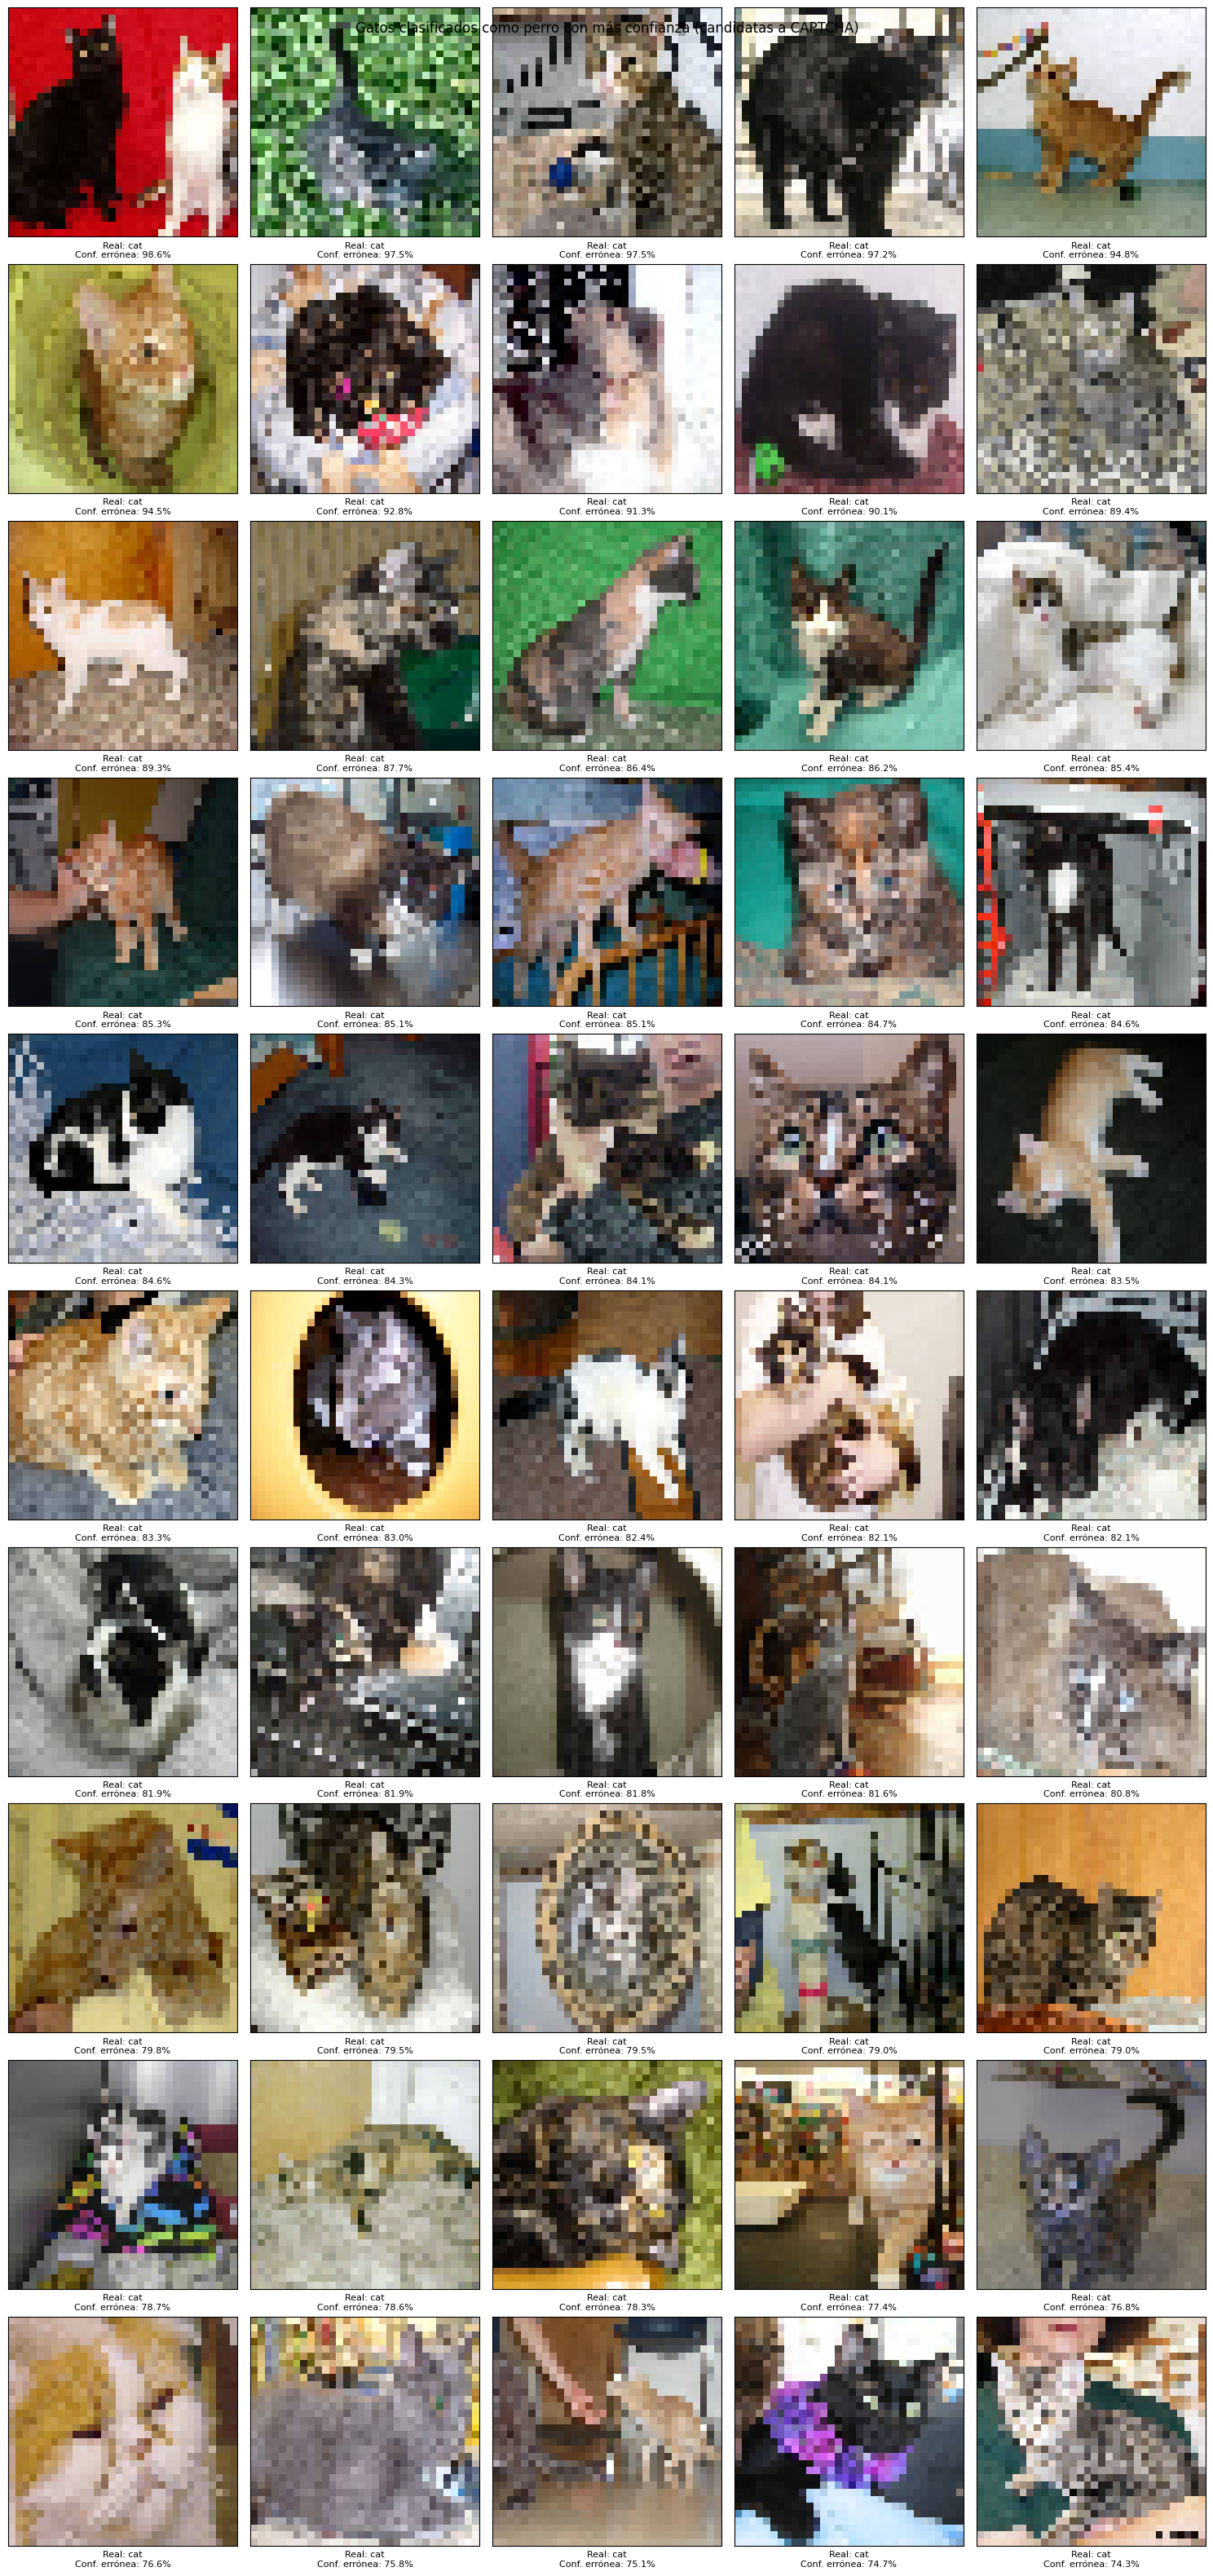

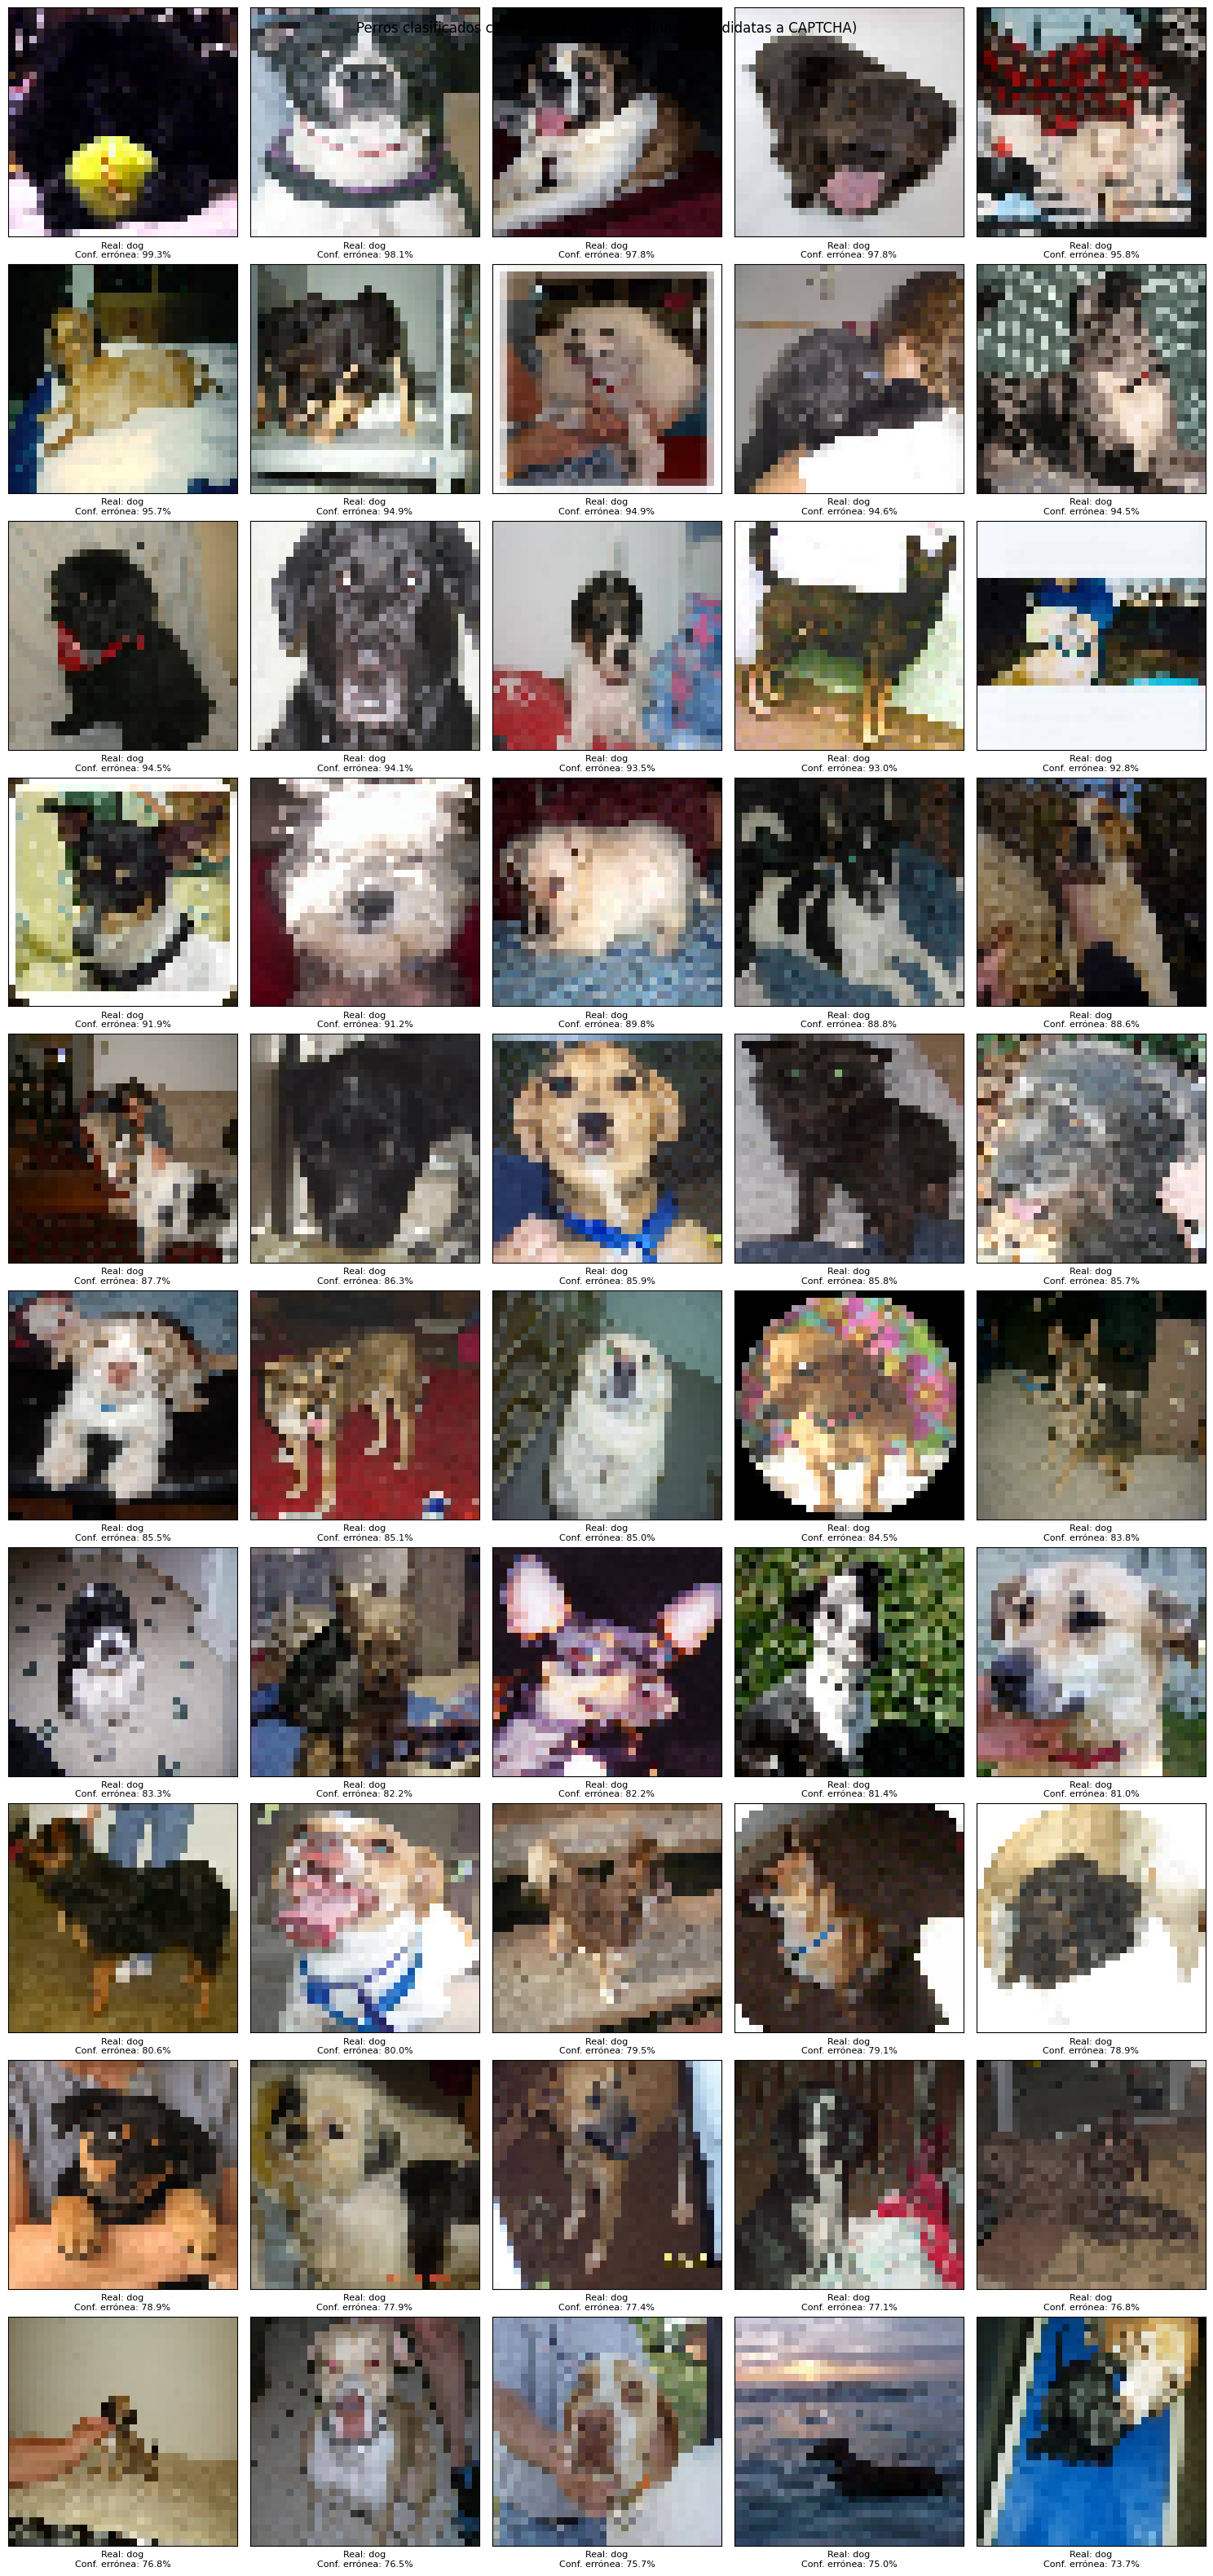

In [30]:
def mostrar_imagenes_dificiles(indices, images, true_labels, pred_probs, titulo):
    n = len(indices)
    if n == 0:
        print(f"No hay imágenes que mostrar para: {titulo}")
        return

    cols = min(5, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3 * cols, 3.2 * rows))
    for i, idx in enumerate(indices):
        plt.subplot(rows, cols, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[idx])

        real = inv_label_map[true_labels[idx]]
        conf_dog = pred_probs[idx]
        conf_erronea = conf_dog if real == "cat" else (1 - conf_dog)
        plt.xlabel(f"Real: {real}\nConf. errónea: {conf_erronea * 100:.1f}%", fontsize=8)

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


mostrar_imagenes_dificiles(
    idx_cats_dificiles, X_test, y_test, y_pred_probs,
    "Gatos clasificados como perro con más confianza (candidatas a CAPTCHA)",
)
mostrar_imagenes_dificiles(
    idx_dogs_dificiles, X_test, y_test, y_pred_probs,
    "Perros clasificados como gato con más confianza (candidatas a CAPTCHA)",
)

In [31]:
seleccion = []
for idx in idx_cats_dificiles:
    seleccion.append({
        "ruta": paths_test[idx],
        "clase_real": "cat",
        "clase_predicha": "dog",
        "confianza_erronea": float(y_pred_probs[idx]),
    })
for idx in idx_dogs_dificiles:
    seleccion.append({
        "ruta": paths_test[idx],
        "clase_real": "dog",
        "clase_predicha": "cat",
        "confianza_erronea": float(1 - y_pred_probs[idx]),
    })

df_seleccion = pd.DataFrame(seleccion).sort_values("confianza_erronea", ascending=False).reset_index(drop=True)
print(f"Total de imágenes seleccionadas para el CAPTCHA: {len(df_seleccion)}")
df_seleccion

Total de imágenes seleccionadas para el CAPTCHA: 100


,ruta,clase_real,clase_predicha,confianza_erronea
0,data\github_test\dog.8764.jpg,dog,cat,0.992742
1,data\github_test\cat.11825.jpg,cat,dog,0.985658
2,data\github_test\dog.9346.jpg,dog,cat,0.980619
3,data\github_test\dog.8215.jpg,dog,cat,0.978105
4,data\github_test\dog.8696.jpg,dog,cat,0.977717
...,...,...,...,...
95,data\github_test\cat.10716.jpg,cat,dog,0.750855
96,data\github_test\dog.9627.jpg,dog,cat,0.749791
97,data\github_test\cat.11563.jpg,cat,dog,0.746665
98,data\github_test\cat.11509.jpg,cat,dog,0.742904


### Extra: repetir el proceso con Image Augmentation

Repetimos los apartados 3 a 5 pero entrenando con un generador de imágenes sintéticas (`ImageDataGenerator`), que aplica transformaciones aleatorias (rotación, desplazamiento, zoom, espejo horizontal...) a cada imagen en cada época. La idea es que el modelo generalice mejor al ver más variabilidad, aunque el dataset de partida siga teniendo el mismo número real de imágenes.

Usamos la misma arquitectura (`construir_modelo_cnn()`) para que la comparación entre "sin aumentado" y "con aumentado" sea justa.

In [32]:
datagen_aug = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2,
)

train_gen = datagen_aug.flow(
    X_train_raw, y_train, batch_size=32, subset="training", seed=RANDOM_STATE,
)
val_gen = datagen_aug.flow(
    X_train_raw, y_train, batch_size=32, subset="validation", seed=RANDOM_STATE,
)

model_aug = construir_modelo_cnn()

early_stopping_aug = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
)

history_aug = model_aug.fit(
    train_gen,
    validation_data=val_gen,
    epochs=60,
    callbacks=[early_stopping_aug],
    verbose=2,
)

Epoch 1/60
100/100 - 5s - 53ms/step - accuracy: 0.5366 - loss: 0.6901 - val_accuracy: 0.6187 - val_loss: 0.6718
Epoch 2/60
100/100 - 4s - 36ms/step - accuracy: 0.5856 - loss: 0.6716 - val_accuracy: 0.6388 - val_loss: 0.6362
Epoch 3/60
100/100 - 3s - 31ms/step - accuracy: 0.6319 - loss: 0.6412 - val_accuracy: 0.6837 - val_loss: 0.6130
Epoch 4/60
100/100 - 5s - 51ms/step - accuracy: 0.6450 - loss: 0.6235 - val_accuracy: 0.6338 - val_loss: 0.6196
Epoch 5/60
100/100 - 4s - 39ms/step - accuracy: 0.6666 - loss: 0.6006 - val_accuracy: 0.6938 - val_loss: 0.5736
Epoch 6/60
100/100 - 4s - 35ms/step - accuracy: 0.6756 - loss: 0.6009 - val_accuracy: 0.7175 - val_loss: 0.5612
Epoch 7/60
100/100 - 5s - 46ms/step - accuracy: 0.6944 - loss: 0.5857 - val_accuracy: 0.7188 - val_loss: 0.5543
Epoch 8/60
100/100 - 7s - 66ms/step - accuracy: 0.7078 - loss: 0.5653 - val_accuracy: 0.7063 - val_loss: 0.5680
Epoch 9/60
100/100 - 4s - 44ms/step - accuracy: 0.7050 - loss: 0.5687 - val_accuracy: 0.7312 - val_loss:

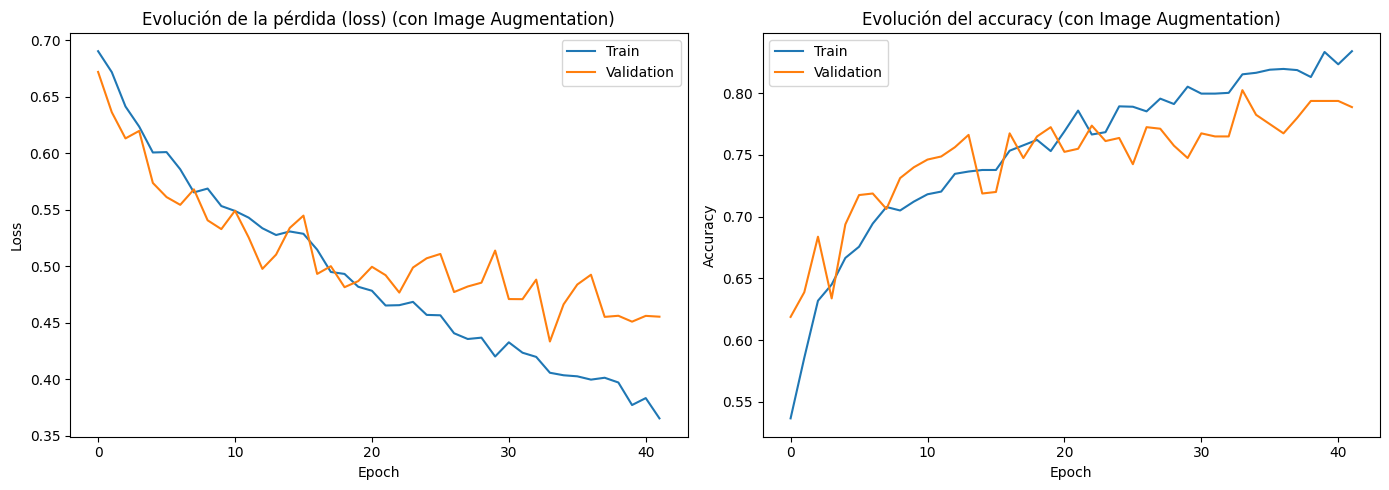

In [33]:
plot_historial(history_aug, titulo_extra="(con Image Augmentation)")

In [34]:
test_loss_aug, test_acc_aug = model_aug.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy (con augmentation): {test_acc_aug:.4f}")
print(f"Test loss (con augmentation):     {test_loss_aug:.4f}")

y_pred_probs_aug = model_aug.predict(X_test, verbose=0).ravel()
y_pred_aug = (y_pred_probs_aug >= 0.5).astype(int)

print(classification_report(y_test, y_pred_aug, target_names=["cat", "dog"]))

Test accuracy (con augmentation): 0.7670
Test loss (con augmentation):     0.4545
              precision    recall  f1-score   support

         cat       0.88      0.62      0.73       500
         dog       0.71      0.92      0.80       500

    accuracy                           0.77      1000
   macro avg       0.79      0.77      0.76      1000
weighted avg       0.79      0.77      0.76      1000



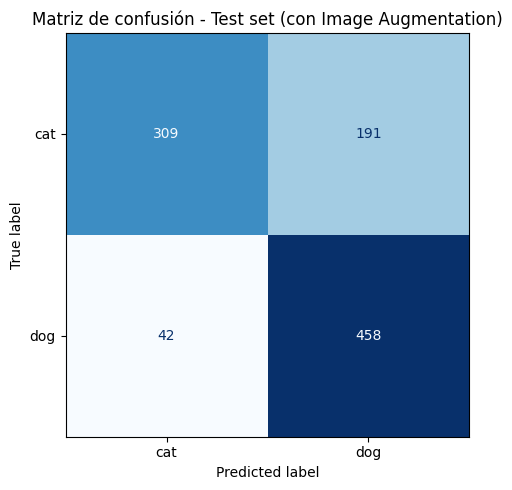

array([[309, 191],
       [ 42, 458]])

In [35]:
cm_aug = confusion_matrix(y_test, y_pred_aug)

fig, ax = plt.subplots(figsize=(6, 5))
disp_aug = ConfusionMatrixDisplay(confusion_matrix=cm_aug, display_labels=["cat", "dog"])
disp_aug.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Test set (con Image Augmentation)")
plt.tight_layout()
plt.show()

cm_aug

[Con augmentation] Gatos mal clasificados disponibles: 191 | seleccionados: 50
[Con augmentation] Perros mal clasificados disponibles: 42 | seleccionados: 42


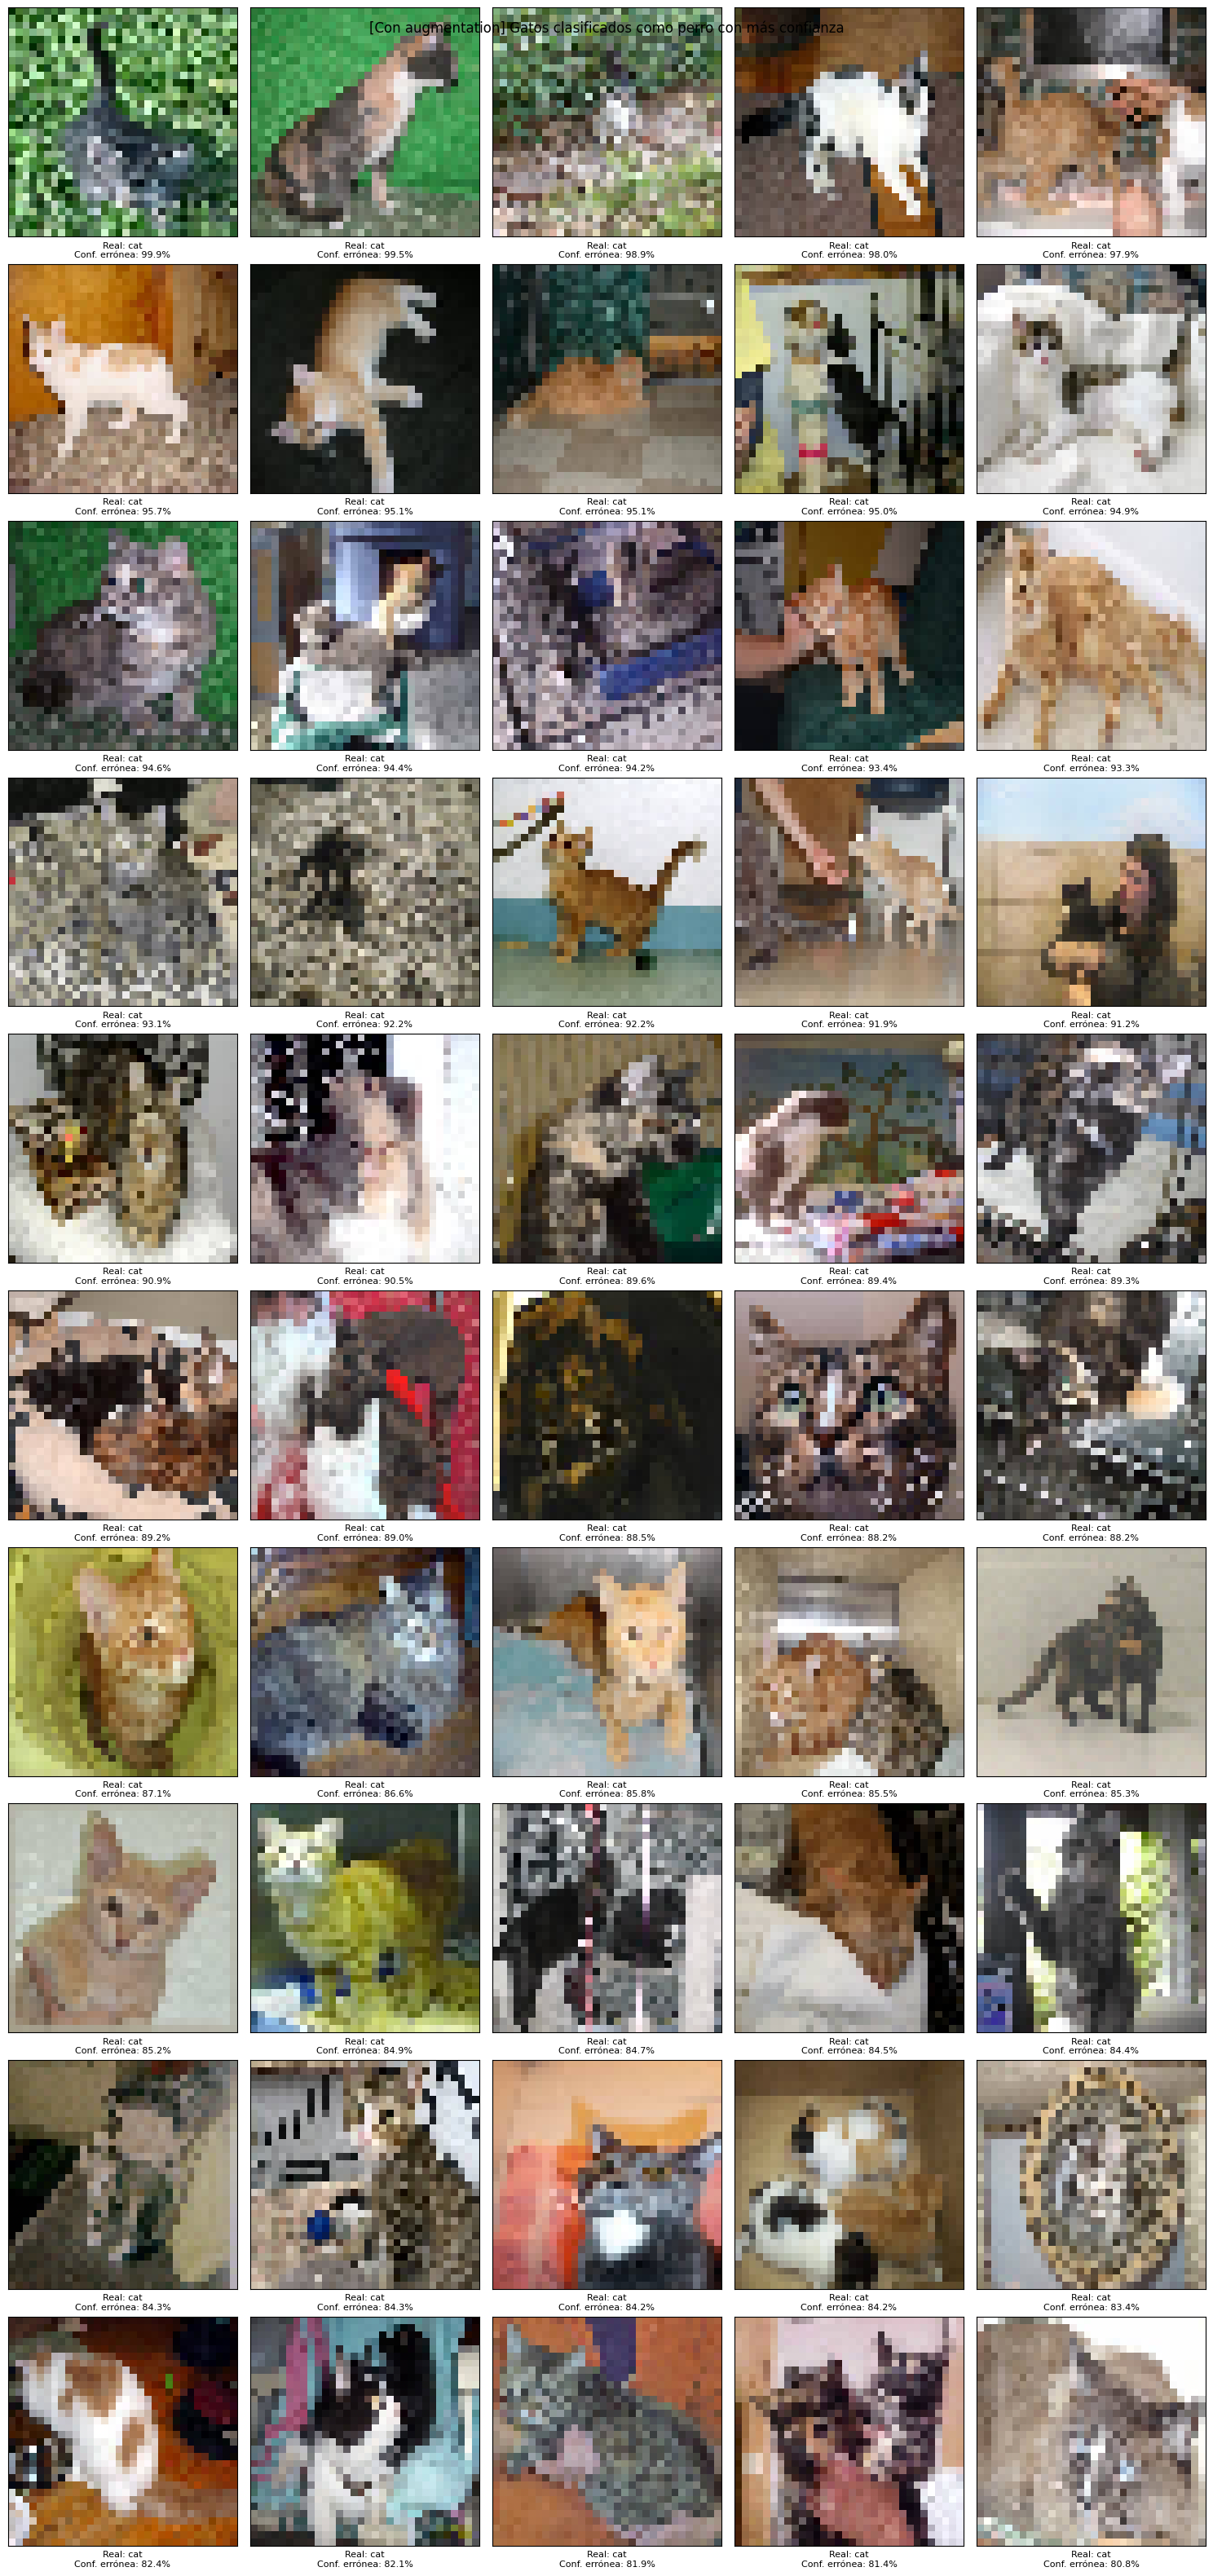

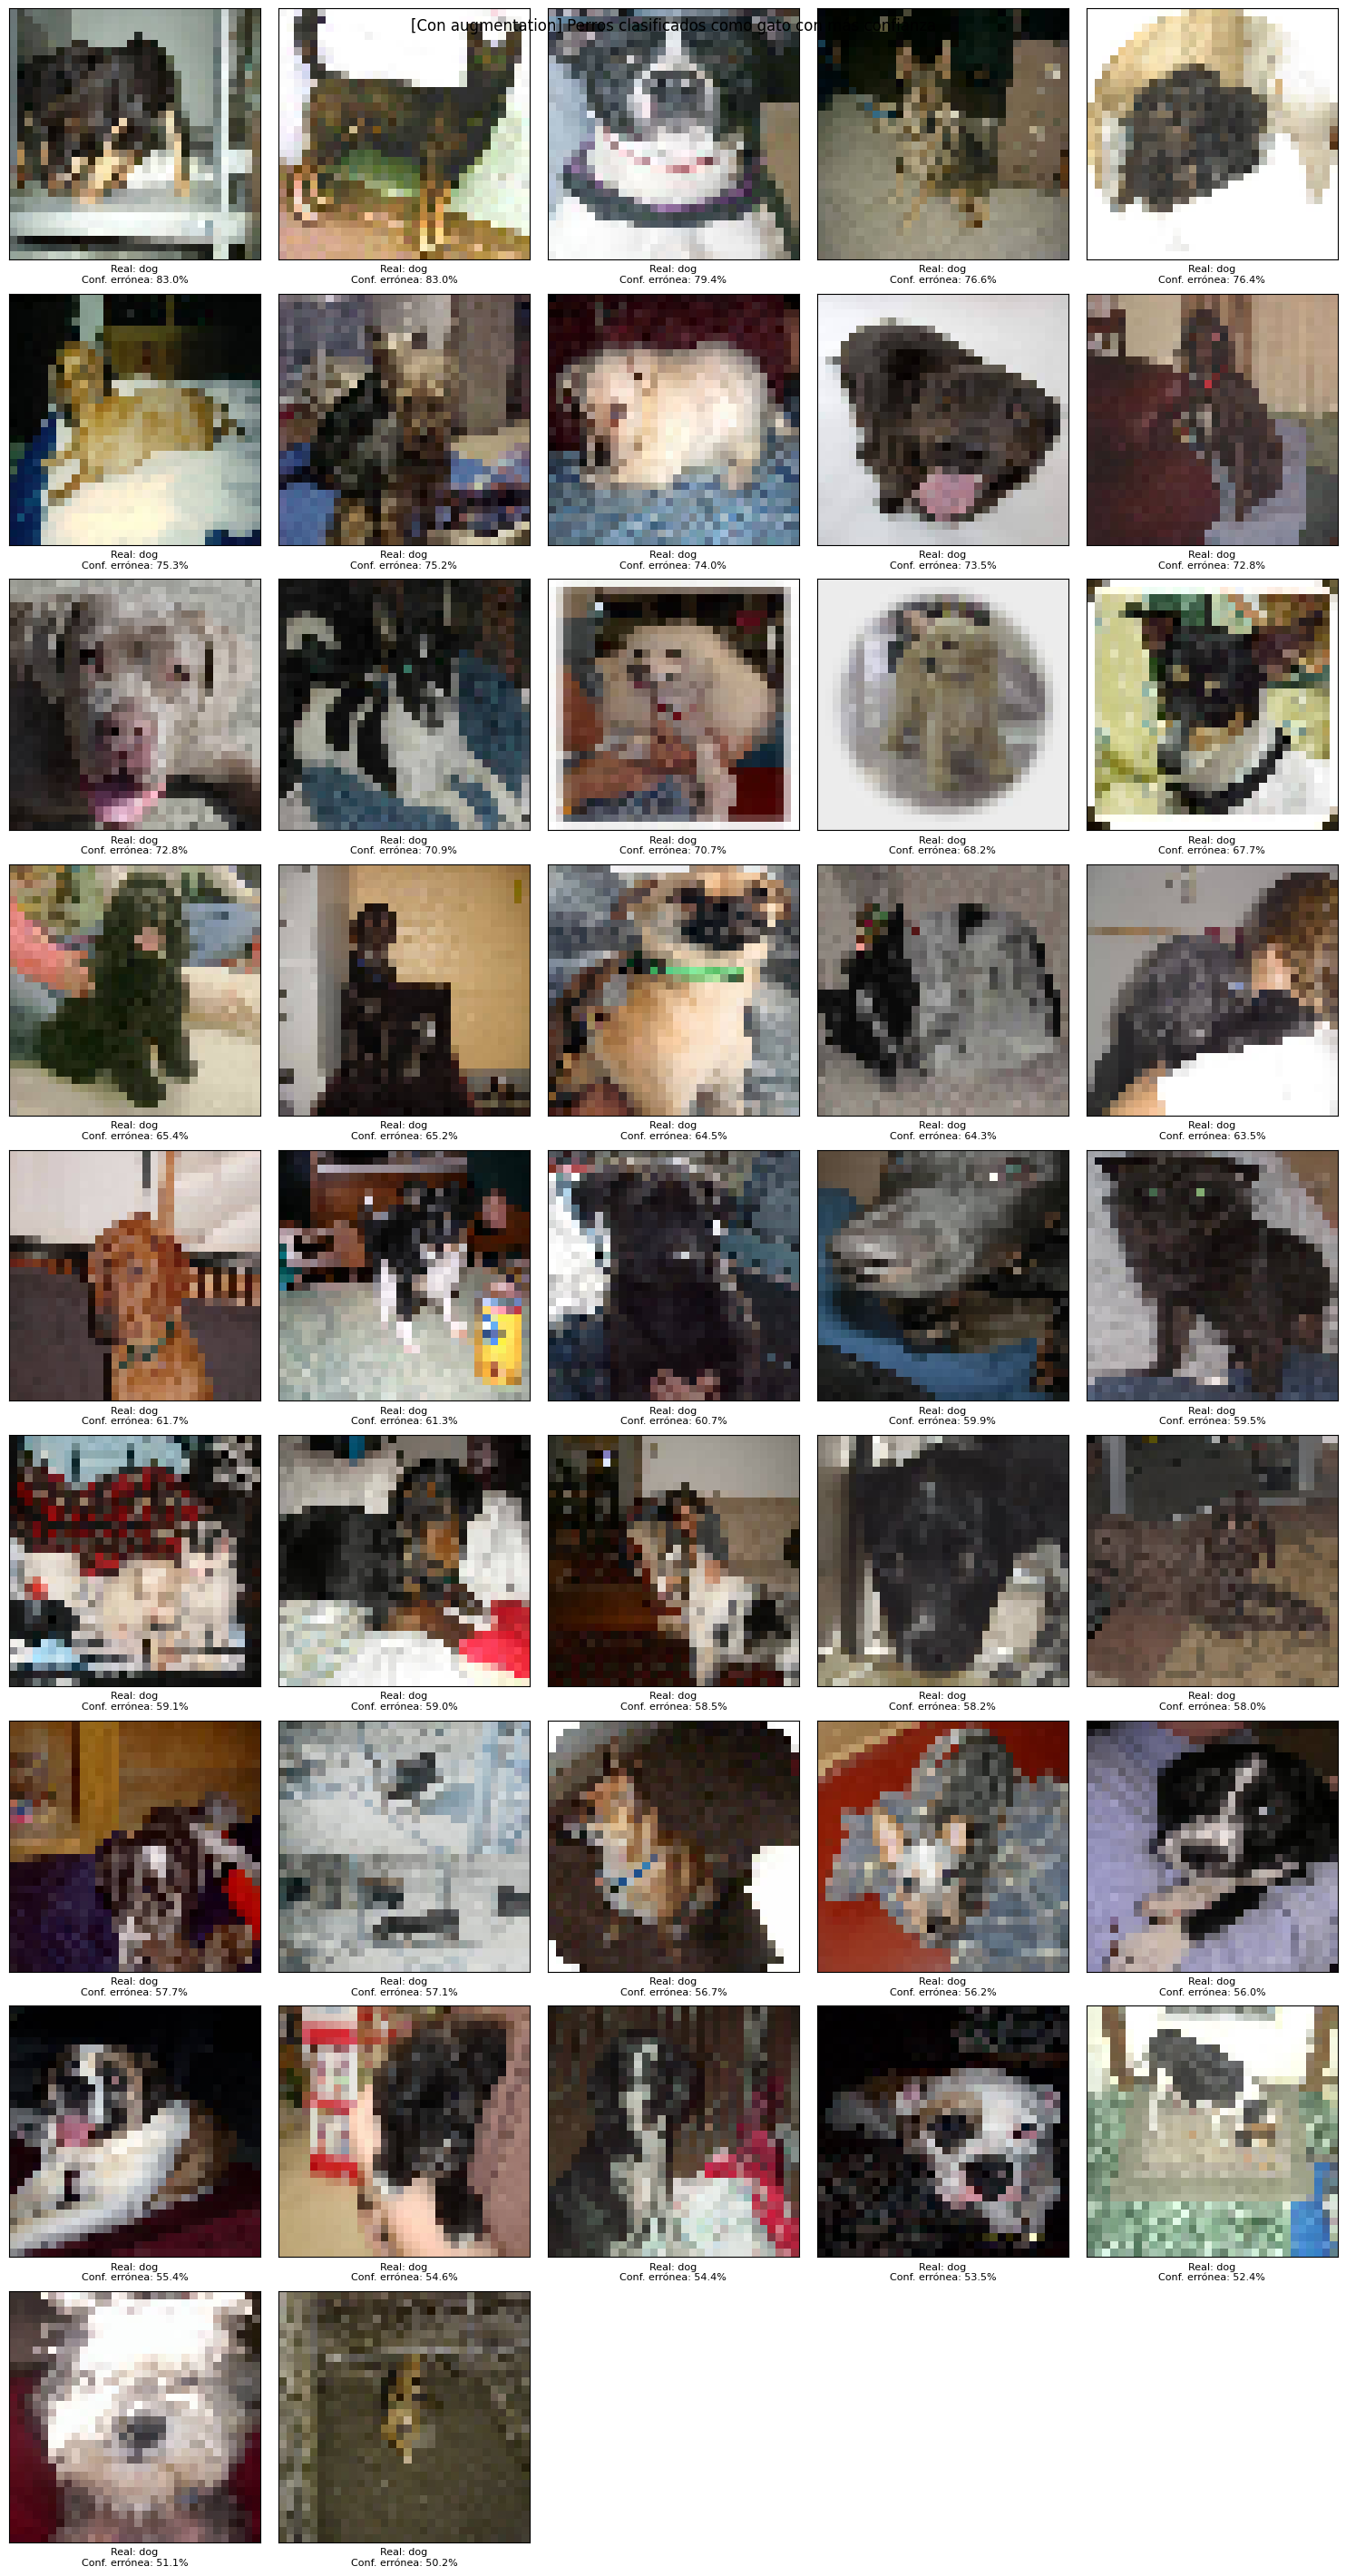

In [36]:
idx_cats_mal_aug = np.where((y_test == 0) & (y_pred_aug == 1))[0]
idx_cats_mal_aug = idx_cats_mal_aug[np.argsort(-y_pred_probs_aug[idx_cats_mal_aug])]
idx_cats_dificiles_aug = idx_cats_mal_aug[:n_cats_dificiles]

idx_dogs_mal_aug = np.where((y_test == 1) & (y_pred_aug == 0))[0]
confianza_dogs_mal_aug = 1 - y_pred_probs_aug[idx_dogs_mal_aug]
idx_dogs_mal_aug = idx_dogs_mal_aug[np.argsort(-confianza_dogs_mal_aug)]
idx_dogs_dificiles_aug = idx_dogs_mal_aug[:n_dogs_dificiles]

print(f"[Con augmentation] Gatos mal clasificados disponibles: {len(idx_cats_mal_aug)} | "
      f"seleccionados: {len(idx_cats_dificiles_aug)}")
print(f"[Con augmentation] Perros mal clasificados disponibles: {len(idx_dogs_mal_aug)} | "
      f"seleccionados: {len(idx_dogs_dificiles_aug)}")

mostrar_imagenes_dificiles(
    idx_cats_dificiles_aug, X_test, y_test, y_pred_probs_aug,
    "[Con augmentation] Gatos clasificados como perro con más confianza",
)
mostrar_imagenes_dificiles(
    idx_dogs_dificiles_aug, X_test, y_test, y_pred_probs_aug,
    "[Con augmentation] Perros clasificados como gato con más confianza",
)

**Comparativa y conclusión:**

* El `EarlyStopping` es especialmente útil aquí: con solo 4000 imágenes de train y una red convolucional con varios millones de parámetros, el riesgo de sobreajuste es alto y sin él el modelo probablemente seguiría "memorizando" el train mucho más allá del punto óptimo de validación.
* El *Image Augmentation* normalmente reduce el hueco entre `loss` de train y de validación (menos overfitting), a cambio de que el entrenamiento converja más despacio (cada época ve variaciones distintas de las mismas imágenes, nunca exactamente los píxeles originales). Con un dataset tan pequeño como este, es habitual que el aumento de datos mejore ligeramente la accuracy de test o, como mínimo, la haga más estable, aunque no siempre es una mejora drástica.
* En ambos casos (con y sin *augmentation*), las imágenes seleccionadas como "difíciles" tienden a repetirse bastante: suelen ser fotos con encuadres poco habituales, mala iluminación, el animal parcialmente oculto, o razas/posturas ambiguas donde hasta a un humano le costaría distinguir a primera vista si es un perro o un gato a 32x32 píxeles. Esas son exactamente las imágenes que interesan para el CAPTCHA, porque son las que peor va a resolver un clasificador automático "malicioso".

### Fin de la práctica

Se han completado los 5 apartados obligatorios (carga y etiquetado de datos a partir del nombre de fichero, mini-EDA y construcción de una CNN con tres bloques Conv+Pooling, entrenamiento con `EarlyStopping`, evaluación con classification report y matriz de confusión, y selección de las imágenes más "difíciles" por clase) y el apartado Extra de *Image Augmentation*.